# iTransformer Last-Block Horizon-Grouped Query Adapter

This section implements the matched horizon-specific topology-transfer mechanism. Predictive-utility source sets are computed from training data and then imposed on the neural forecaster as specified in the paper.


In [1]:
from pathlib import Path
from types import SimpleNamespace
import gc
import importlib
import math
import random
import sys
import time
import traceback
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("Device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    free_b, total_b = torch.cuda.mem_get_info()
    print(
        f"CUDA memory: {free_b/1024**3:.1f} / "
        f"{total_b/1024**3:.1f} GiB free"
    )


Python: 3.8.10 (default, Mar 15 2022, 12:22:08) 
[GCC 9.4.0]
PyTorch: 2.4.1+cu121
Device: cuda
GPU: NVIDIA A100-SXM4-80GB
CUDA memory: 76.0 / 79.2 GiB free


## 1. Fixed experiment configuration


In [2]:
SEED = 2026
SEQ_LEN = 96
LABEL_LEN = 48

CONDITIONS = [
    ("Electricity", 192),
    ("ETTh1", 336),
    ("ETTm1", 336),
    ("Solar", 720),
]

VARIANTS = [
    "SharedQueryAdapter",
    "HorizonGroupedQueryAdapter",
]

N_HORIZON_GROUPS = 4
ADAPTER_RANK = 8

ADAPTER_LR = 2e-3
WEIGHT_DECAY = 1e-4

MAX_EPOCHS = 15
PATIENCE = 5
GRAD_CLIP = 1.0

NUM_WORKERS = 2
RESUME = True

ROUTE_TOPK = 5
ROUTE_DIAGNOSTIC_BATCHES = 1

PROJECT_ROOT_CANDIDATES = [
    Path("/data/code/2026_08"),
    Path.cwd(),
]

PROJECT_ROOT = next(
    (p for p in PROJECT_ROOT_CANDIDATES if p.exists()),
    Path.cwd(),
).resolve()

BASELINE_ROOT = (
    PROJECT_ROOT
    / "results_external_baselines_phase1_direct"
)

PHASE1_RESULT_CSV = (
    BASELINE_ROOT
    / "baseline_results_phase1_direct.csv"
)

OUTPUT_DIR = (
    PROJECT_ROOT
    / "results_itransformer_lastblock_horizon_grouped_query_adapter"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("Conditions:", CONDITIONS)
print("Variants:", VARIANTS)
print("Groups:", N_HORIZON_GROUPS)
print("Adapter rank:", ADAPTER_RANK)


PROJECT_ROOT: /data/code/2026_08
OUTPUT_DIR: /data/code/2026_08/results_itransformer_lastblock_horizon_grouped_query_adapter
Conditions: [('Electricity', 192), ('ETTh1', 336), ('ETTm1', 336), ('Solar', 720)]
Variants: ['SharedQueryAdapter', 'HorizonGroupedQueryAdapter']
Groups: 4
Adapter rank: 8


In [3]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(SEED)

if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True


def choose_batch_size(dataset_name, H):
    batch = 32

    if dataset_name == "Electricity":
        batch = min(batch, 16)

        if H >= 336:
            batch = min(batch, 8)

    if dataset_name == "Solar":
        batch = min(batch, 16)

    return batch


def horizon_group_bounds(H, G=N_HORIZON_GROUPS):
    bounds = np.linspace(
        0,
        H,
        G + 1,
        dtype=int,
    ).tolist()

    groups = [
        (int(bounds[g]), int(bounds[g + 1]))
        for g in range(G)
    ]

    assert groups[0][0] == 0
    assert groups[-1][1] == H

    covered = sum(
        b - a
        for a, b in groups
    )

    assert covered == H

    return groups


for H in sorted(
    set(h for _, h in CONDITIONS)
):
    print(
        "H=",
        H,
        "groups=",
        [
            (a + 1, b)
            for a, b
            in horizon_group_bounds(H)
        ],
    )


H= 192 groups= [(1, 48), (49, 96), (97, 144), (145, 192)]
H= 336 groups= [(1, 84), (85, 168), (169, 252), (253, 336)]
H= 720 groups= [(1, 180), (181, 360), (361, 540), (541, 720)]


## 2. Load official Time-Series-Library iTransformer


In [4]:
TSLIB_CANDIDATES = [
    Path("/data/Time-Series-Library"),
    Path("/data/Time-Series-Library_v2"),
    Path("/data/Time-Series-Library"),
    PROJECT_ROOT / "Time-Series-Library",
    PROJECT_ROOT / "Time-Series-Library_v2",
]


def is_tslib_root(p):
    p = Path(p)

    return (
        p.is_dir()
        and (p / "models" / "iTransformer.py").exists()
        and (p / "layers" / "Transformer_EncDec.py").exists()
        and (p / "layers" / "SelfAttention_Family.py").exists()
    )


TSL_ROOT = next(
    (
        p.resolve()
        for p in TSLIB_CANDIDATES
        if is_tslib_root(p)
    ),
    None,
)

if TSL_ROOT is None:
    raise FileNotFoundError(
        "Time-Series-Library source not found."
    )

if str(TSL_ROOT) not in sys.path:
    sys.path.insert(
        0,
        str(TSL_ROOT),
    )

iTransformer_module = importlib.import_module(
    "models.iTransformer"
)

print("TSLib:", TSL_ROOT)


TSLib: /data/Time-Series-Library


## 3. Dataset protocol identical to Phase-1


In [5]:
DATASET_FILES = {
    "Electricity": Path(
        "/data/dataset/electricity/electricity.csv"
    ),
    "Solar": Path(
        "/data/dataset/solar/solar_AL.txt"
    ),
    "ETTh1": Path(
        "/data/dataset/ETT-small/ETTh1.csv"
    ),
    "ETTm1": Path(
        "/data/dataset/ETT-small/ETTm1.csv"
    ),
}

DATASET_SPECS = {
    "Electricity": {
        "channels": 321,
        "freq": "h",
    },
    "Solar": {
        "channels": 137,
        "freq": "h",
    },
    "ETTh1": {
        "channels": 7,
        "freq": "h",
    },
    "ETTm1": {
        "channels": 7,
        "freq": "t",
    },
}


def load_numeric_series(dataset_name, path):
    path = Path(path)

    if path.suffix.lower() == ".csv":
        df = pd.read_csv(path)

        date_col = None

        for candidate in [
            "date",
            "datetime",
            "timestamp",
            "time",
        ]:
            if candidate in df.columns:
                date_col = candidate
                break

        if date_col is None:
            first_col = df.columns[0]

            if not pd.api.types.is_numeric_dtype(
                df[first_col]
            ):
                date_col = first_col

        if date_col is not None:
            df = df.drop(
                columns=[date_col]
            )

        df = df.select_dtypes(
            include=[np.number]
        )

        x = df.to_numpy(
            dtype=np.float32
        )

    else:
        try:
            x = np.loadtxt(
                path,
                delimiter=",",
                dtype=np.float32,
            )
        except Exception:
            x = np.loadtxt(
                path,
                dtype=np.float32,
            )

        if x.ndim == 1:
            x = x[:, None]

    if x.ndim != 2:
        raise ValueError(
            f"{dataset_name}: unexpected shape {x.shape}"
        )

    if not np.isfinite(x).all():
        raise ValueError(
            f"{dataset_name}: non-finite values"
        )

    return x


def split_boundaries(dataset_name, T):
    if dataset_name == "ETTh1":
        train_end = 12 * 30 * 24
        val_end = train_end + 4 * 30 * 24
        test_end = val_end + 4 * 30 * 24

        return (
            min(train_end, T),
            min(val_end, T),
            min(test_end, T),
        )

    if dataset_name == "ETTm1":
        unit = 30 * 24 * 4

        train_end = 12 * unit
        val_end = train_end + 4 * unit
        test_end = val_end + 4 * unit

        return (
            min(train_end, T),
            min(val_end, T),
            min(test_end, T),
        )

    return (
        int(0.70 * T),
        int(0.80 * T),
        T,
    )


def load_and_normalize(dataset_name):
    raw = load_numeric_series(
        dataset_name,
        DATASET_FILES[dataset_name],
    )

    T, C = raw.shape

    (
        train_end,
        val_end,
        test_end,
    ) = split_boundaries(
        dataset_name,
        T,
    )

    mean = raw[
        :train_end
    ].mean(
        axis=0,
        keepdims=True,
    )

    std = raw[
        :train_end
    ].std(
        axis=0,
        keepdims=True,
    )

    std = np.maximum(
        std,
        1e-6,
    )

    x = (
        raw - mean
    ) / std

    return (
        x.astype(np.float32),
        {
            "T": T,
            "C": C,
            "train_end": train_end,
            "val_end": val_end,
            "test_end": test_end,
        },
    )


class ForecastDataset(Dataset):
    def __init__(
        self,
        data,
        seq_len,
        label_len,
        pred_len,
        target_start_min,
        target_end_exclusive,
    ):
        self.data = torch.from_numpy(
            data
        ).float()

        self.seq_len = int(seq_len)
        self.label_len = int(label_len)
        self.pred_len = int(pred_len)

        first_t = max(
            self.seq_len,
            self.label_len,
            int(target_start_min),
        )

        last_t = (
            int(target_end_exclusive)
            -
            self.pred_len
        )

        self.origins = np.arange(
            first_t,
            last_t + 1,
            dtype=np.int64,
        )

        if len(self.origins) == 0:
            raise RuntimeError(
                "No valid forecasting windows."
            )

    def __len__(self):
        return len(
            self.origins
        )

    def __getitem__(self, idx):
        t = int(
            self.origins[idx]
        )

        x = self.data[
            t-self.seq_len:
            t
        ]

        y = self.data[
            t-self.label_len:
            t+self.pred_len
        ]

        return x, y


def prepare_datasets(dataset_name, H):
    x, meta = load_and_normalize(
        dataset_name
    )

    expected_C = DATASET_SPECS[
        dataset_name
    ][
        "channels"
    ]

    if meta["C"] != expected_C:
        raise RuntimeError(
            f"{dataset_name}: detected C={meta['C']}, "
            f"expected {expected_C}"
        )

    train_ds = ForecastDataset(
        x,
        SEQ_LEN,
        LABEL_LEN,
        H,
        target_start_min=SEQ_LEN,
        target_end_exclusive=meta[
            "train_end"
        ],
    )

    val_ds = ForecastDataset(
        x,
        SEQ_LEN,
        LABEL_LEN,
        H,
        target_start_min=meta[
            "train_end"
        ],
        target_end_exclusive=meta[
            "val_end"
        ],
    )

    test_ds = ForecastDataset(
        x,
        SEQ_LEN,
        LABEL_LEN,
        H,
        target_start_min=meta[
            "val_end"
        ],
        target_end_exclusive=meta[
            "test_end"
        ],
    )

    return (
        x,
        train_ds,
        val_ds,
        test_ds,
        meta,
    )


def make_loaders(
    train_ds,
    val_ds,
    test_ds,
    batch_size,
    seed,
):
    generator = torch.Generator()

    generator.manual_seed(
        seed + 100000
    )

    common = dict(
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
        drop_last=False,
    )

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        generator=generator,
        **common,
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        **common,
    )

    test_loader = DataLoader(
        test_ds,
        batch_size=batch_size,
        shuffle=False,
        **common,
    )

    return (
        train_loader,
        val_loader,
        test_loader,
    )


## 4. Exact Phase-1 iTransformer


In [6]:
def build_itransformer_args(dataset_name, H):
    spec = DATASET_SPECS[
        dataset_name
    ]

    return SimpleNamespace(
        task_name="long_term_forecast",
        model="iTransformer",

        seq_len=SEQ_LEN,
        label_len=LABEL_LEN,
        pred_len=H,

        enc_in=spec[
            "channels"
        ],
        dec_in=spec[
            "channels"
        ],
        c_out=spec[
            "channels"
        ],

        e_layers=3,
        d_layers=1,
        n_heads=8,
        d_model=512,
        d_ff=512,
        factor=3,
        dropout=0.1,

        embed="timeF",
        freq=spec[
            "freq"
        ],
        activation="gelu",
        output_attention=False,

        class_strategy="projection",
        use_norm=1,

        moving_avg=25,
        distil=True,
        top_k=5,
        num_kernels=6,
        seasonal_patterns="Monthly",
        inverse=False,
    )


def condition_dir(dataset_name, H):
    return (
        BASELINE_ROOT
        / "iTransformer"
        / dataset_name
        / f"H{H}"
    )


def build_and_load_itransformer(dataset_name, H):
    args = build_itransformer_args(
        dataset_name,
        H,
    )

    model = (
        iTransformer_module
        .Model(args)
        .float()
        .to(DEVICE)
    )

    checkpoint = (
        condition_dir(
            dataset_name,
            H,
        )
        / "best_model.pt"
    )

    if not checkpoint.exists():
        raise FileNotFoundError(
            checkpoint
        )

    state = torch.load(
        checkpoint,
        map_location="cpu",
    )

    model.load_state_dict(
        state,
        strict=True,
    )

    model.eval()

    for p in model.parameters():
        p.requires_grad = False

    # Structural checks needed by the custom last-block path.
    assert hasattr(
        model.encoder,
        "attn_layers",
    )

    assert (
        len(
            model.encoder.attn_layers
        )
        >=
        1
    )

    last_layer = (
        model.encoder
        .attn_layers[-1]
    )

    assert hasattr(
        last_layer,
        "attention",
    )

    for attr in [
        "query_projection",
        "key_projection",
        "value_projection",
        "out_projection",
        "n_heads",
    ]:
        assert hasattr(
            last_layer.attention,
            attr,
        ), attr

    return model


def load_phase1_result(dataset_name, H):
    p = (
        condition_dir(
            dataset_name,
            H,
        )
        / "result.csv"
    )

    if not p.exists():
        raise FileNotFoundError(
            p
        )

    df = pd.read_csv(
        p
    )

    if len(df) != 1:
        raise RuntimeError(
            f"Unexpected rows: {p}"
        )

    return (
        df.iloc[0]
        .to_dict()
    )


## 5. Last-block horizon-grouped query adapter


In [7]:
class LastBlockHorizonGroupedQueryAdapter(
    nn.Module
):
    """
    Modify only the Q path inside the final iTransformer EncoderLayer.

    SharedQueryAdapter:
        one rank-wise scale vector shared by all horizon groups.

    HorizonGroupedQueryAdapter:
        one rank-wise scale vector per horizon group.

    Everything else in the original iTransformer remains frozen.
    """

    def __init__(
        self,
        base_model,
        variant,
        channels,
        n_groups=4,
        rank=8,
    ):
        super().__init__()

        if variant not in {
            "SharedQueryAdapter",
            "HorizonGroupedQueryAdapter",
        }:
            raise ValueError(
                variant
            )

        self.base = base_model
        self.variant = variant
        self.C = int(
            channels
        )
        self.H = int(
            base_model.pred_len
        )
        self.G = int(
            n_groups
        )
        self.rank = int(
            rank
        )

        self.groups = horizon_group_bounds(
            self.H,
            self.G,
        )

        self.d_model = int(
            base_model.projection.in_features
        )

        for p in self.base.parameters():
            p.requires_grad = False

        self.base.eval()

        self.last_layer = (
            self.base.encoder
            .attn_layers[-1]
        )

        self.final_norm = (
            self.base.encoder.norm
        )

        self.attn_layer = (
            self.last_layer.attention
        )

        self.n_heads = int(
            self.attn_layer.n_heads
        )

        self.down = nn.Linear(
            self.d_model,
            self.rank,
            bias=False,
        )

        self.up = nn.Linear(
            self.rank,
            self.d_model,
            bias=False,
        )

        # Normal low-rank basis.
        nn.init.kaiming_uniform_(
            self.down.weight,
            a=math.sqrt(5),
        )

        # Exact iTransformer at initialization.
        nn.init.zeros_(
            self.up.weight
        )

        n_scale_rows = (
            1
            if (
                self.variant
                ==
                "SharedQueryAdapter"
            )
            else
            self.G
        )

        self.group_scale = nn.Parameter(
            torch.ones(
                n_scale_rows,
                self.rank,
            )
        )

        self.force_identity = False

    def train(
        self,
        mode=True,
    ):
        super().train(
            mode
        )

        # Frozen TSLib modules remain deterministic.
        self.base.eval()

        return self

    def adapter_parameters(
        self,
    ):
        return [
            self.down.weight,
            self.up.weight,
            self.group_scale,
        ]

    def _scale_for_group(
        self,
        g,
    ):
        row = (
            0
            if (
                self.variant
                ==
                "SharedQueryAdapter"
            )
            else
            int(g)
        )

        return self.group_scale[
            row
        ]

    @torch.no_grad()
    def _normalize_and_prefix(
        self,
        x,
    ):
        """
        Reproduce iTransformer forecast normalization and run
        embedding + all encoder blocks except the last one.
        """
        means = (
            x
            .mean(
                1,
                keepdim=True,
            )
            .detach()
        )

        x_norm = (
            x - means
        )

        stdev = torch.sqrt(
            torch.var(
                x_norm,
                dim=1,
                keepdim=True,
                unbiased=False,
            )
            +
            1e-5
        )

        x_norm = (
            x_norm
            /
            stdev
        )

        _, _, N = (
            x_norm.shape
        )

        enc = self.base.enc_embedding(
            x_norm,
            None,
        )

        prefix_layers = (
            self.base.encoder
            .attn_layers[:-1]
        )

        for layer in prefix_layers:
            enc, _ = layer(
                enc,
                attn_mask=None,
                tau=None,
                delta=None,
            )

        return (
            enc.detach(),
            means,
            stdev,
            N,
        )

    def _adapt_query_projection(
        self,
        q0,
        g,
    ):
        """
        q0: [B, C, d_model], already projected by original W_Q.
        """
        scale = self._scale_for_group(
            g
        )

        low = self.down(
            q0
        )

        low = (
            low
            *
            scale[
                None,
                None,
                :
            ]
        )

        delta_q = self.up(
            low
        )

        return (
            q0
            +
            delta_q
        )

    def _last_layer_group(
        self,
        x,
        g,
        return_attention=False,
    ):
        """
        Faithful reimplementation of official EncoderLayer.forward,
        except that the query projection is adapted.

        Original K, V, attention output projection, residual,
        norm1, FFN, norm2 are reused exactly.
        """
        attn = self.attn_layer

        B, L, _ = (
            x.shape
        )

        Hh = self.n_heads

        q0 = attn.query_projection(
            x
        )

        q_full = self._adapt_query_projection(
            q0,
            g,
        )

        k_full = attn.key_projection(
            x
        )

        v_full = attn.value_projection(
            x
        )

        q = q_full.view(
            B,
            L,
            Hh,
            -1,
        )

        k = k_full.view(
            B,
            L,
            Hh,
            -1,
        )

        v = v_full.view(
            B,
            L,
            Hh,
            -1,
        )

        inner_out, _ = (
            attn.inner_attention(
                q,
                k,
                v,
                attn_mask=None,
                tau=None,
                delta=None,
            )
        )

        inner_out = inner_out.view(
            B,
            L,
            -1,
        )

        new_x = attn.out_projection(
            inner_out
        )

        # Official EncoderLayer lines:
        # x = x + dropout(new_x)
        # y = x = norm1(x)
        # FFN
        # return norm2(x+y)
        x_res = (
            x
            +
            self.last_layer.dropout(
                new_x
            )
        )

        y = x_norm1 = (
            self.last_layer.norm1(
                x_res
            )
        )

        y = self.last_layer.dropout(
            self.last_layer.activation(
                self.last_layer.conv1(
                    y.transpose(
                        -1,
                        1,
                    )
                )
            )
        )

        y = self.last_layer.dropout(
            self.last_layer.conv2(
                y
            ).transpose(
                -1,
                1,
            )
        )

        out = self.last_layer.norm2(
            x_norm1
            +
            y
        )

        if self.final_norm is not None:
            out = self.final_norm(
                out
            )

        attention = None

        if return_attention:
            d_head = q.shape[
                -1
            ]

            scores = torch.einsum(
                "blhe,bshe->bhls",
                q,
                k,
            )

            attention = torch.softmax(
                scores
                /
                math.sqrt(
                    d_head
                ),
                dim=-1,
            )

        return (
            out,
            attention,
        )

    def _project_group(
        self,
        z_group,
        start,
        end,
        N,
    ):
        """
        Use exactly the corresponding rows of the frozen original
        iTransformer projection.
        """
        weight = self.base.projection.weight[
            start:
            end,
            :
        ]

        bias = (
            None
            if (
                self.base.projection.bias
                is None
            )
            else
            self.base.projection.bias[
                start:
                end
            ]
        )

        # [B, token, group_H] -> [B, group_H, channel]
        pred = F.linear(
            z_group,
            weight,
            bias,
        )

        pred = (
            pred
            .permute(
                0,
                2,
                1,
            )
            [
                :,
                :,
                :N,
            ]
        )

        return pred

    def forward(
        self,
        x,
    ):
        (
            prefix,
            means,
            stdev,
            N,
        ) = self._normalize_and_prefix(
            x
        )

        if self.force_identity:
            # Exact original final block.
            z, _ = self.last_layer(
                prefix,
                attn_mask=None,
                tau=None,
                delta=None,
            )

            if self.final_norm is not None:
                z = self.final_norm(
                    z
                )

            pred_norm = (
                self.base.projection(
                    z
                )
                .permute(
                    0,
                    2,
                    1,
                )
                [
                    :,
                    :,
                    :N,
                ]
            )

        elif (
            self.variant
            ==
            "SharedQueryAdapter"
        ):
            # Same adapted final-block relation for every horizon.
            z_shared, _ = self._last_layer_group(
                prefix,
                0,
                return_attention=False,
            )

            pred_norm = (
                self.base.projection(
                    z_shared
                )
                .permute(
                    0,
                    2,
                    1,
                )
                [
                    :,
                    :,
                    :N,
                ]
            )

        else:
            group_predictions = []

            for g, (
                start,
                end,
            ) in enumerate(
                self.groups
            ):
                z_g, _ = self._last_layer_group(
                    prefix,
                    g,
                    return_attention=False,
                )

                pred_g = self._project_group(
                    z_g,
                    start,
                    end,
                    N,
                )

                group_predictions.append(
                    pred_g
                )

            pred_norm = torch.cat(
                group_predictions,
                dim=1,
            )

        pred = (
            pred_norm
            *
            stdev[
                :,
                0,
                :
            ]
            .unsqueeze(
                1
            )
            +
            means[
                :,
                0,
                :
            ]
            .unsqueeze(
                1
            )
        )

        return pred

    @torch.no_grad()
    def group_attention(
        self,
        x,
    ):
        """
        Head-averaged last-block attention for every horizon group.

        Returns:
            [B, G, C, C]
        """
        (
            prefix,
            _,
            _,
            N,
        ) = self._normalize_and_prefix(
            x
        )

        attention_groups = []

        for g in range(
            self.G
        ):
            actual_g = (
                0
                if (
                    self.variant
                    ==
                    "SharedQueryAdapter"
                )
                else
                g
            )

            _, attn = self._last_layer_group(
                prefix,
                actual_g,
                return_attention=True,
            )

            # Only actual channel tokens.
            attn = attn[
                :,
                :,
                :N,
                :N,
            ]

            # Average heads.
            attn = attn.mean(
                dim=1
            )

            attention_groups.append(
                attn
            )

        return torch.stack(
            attention_groups,
            dim=1,
        )


## 6. Evaluation


In [8]:
@torch.no_grad()
def evaluate_base(
    base,
    loader,
    H,
):
    base.eval()

    sse = 0.0
    sae = 0.0
    n = 0

    for x, y in loader:
        x = (
            x.float()
            .to(
                DEVICE,
                non_blocking=True,
            )
        )

        y = (
            y.float()
            .to(
                DEVICE,
                non_blocking=True,
            )
        )

        pred = base(
            x,
            None,
            None,
            None,
        )[
            :,
            -H:,
            :
        ]

        target = y[
            :,
            -H:,
            :
        ]

        err = pred - target

        sse += (
            err.square()
            .sum()
            .item()
        )

        sae += (
            err.abs()
            .sum()
            .item()
        )

        n += err.numel()

    return (
        sse / n,
        sae / n,
    )


@torch.no_grad()
def evaluate_model(
    model,
    loader,
    H,
):
    model.eval()

    sse = 0.0
    sae = 0.0
    n = 0

    step_sse = None
    step_sae = None
    step_n = 0

    for x, y in loader:
        x = (
            x.float()
            .to(
                DEVICE,
                non_blocking=True,
            )
        )

        y = (
            y.float()
            .to(
                DEVICE,
                non_blocking=True,
            )
        )

        pred = model(
            x
        )

        target = y[
            :,
            -H:,
            :
        ]

        err = pred - target

        sse += (
            err.square()
            .sum()
            .item()
        )

        sae += (
            err.abs()
            .sum()
            .item()
        )

        n += err.numel()

        this_sse = (
            err.square()
            .sum(
                dim=(
                    0,
                    2,
                )
            )
            .detach()
            .cpu()
        )

        this_sae = (
            err.abs()
            .sum(
                dim=(
                    0,
                    2,
                )
            )
            .detach()
            .cpu()
        )

        if step_sse is None:
            step_sse = this_sse
            step_sae = this_sae

        else:
            step_sse += this_sse
            step_sae += this_sae

        step_n += (
            target.shape[
                0
            ]
            *
            target.shape[
                2
            ]
        )

    return (
        sse / n,
        sae / n,
        (
            step_sse
            /
            step_n
        ).numpy(),
        (
            step_sae
            /
            step_n
        ).numpy(),
    )


## 7. Train with epoch-0 identity fallback


In [9]:
def train_adapter(
    model,
    train_loader,
    val_loader,
    H,
    baseline_val_mse,
):
    optimizer = torch.optim.AdamW(
        model.adapter_parameters(),
        lr=ADAPTER_LR,
        weight_decay=WEIGHT_DECAY,
    )

    best_val = float(
        baseline_val_mse
    )

    best_epoch = 0
    best_state = None

    bad = 0
    history = []

    for epoch in range(
        1,
        MAX_EPOCHS + 1,
    ):
        model.train()
        model.force_identity = False

        train_sse = 0.0
        train_n = 0

        for x, y in train_loader:
            x = (
                x.float()
                .to(
                    DEVICE,
                    non_blocking=True,
                )
            )

            y = (
                y.float()
                .to(
                    DEVICE,
                    non_blocking=True,
                )
            )

            target = y[
                :,
                -H:,
                :
            ]

            optimizer.zero_grad(
                set_to_none=True
            )

            pred = model(
                x
            )

            loss = F.mse_loss(
                pred,
                target,
            )

            if not torch.isfinite(
                loss
            ):
                raise FloatingPointError(
                    "Non-finite loss"
                )

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.adapter_parameters(),
                GRAD_CLIP,
            )

            optimizer.step()

            train_sse += (
                (
                    pred.detach()
                    -
                    target
                )
                .square()
                .sum()
                .item()
            )

            train_n += target.numel()

        (
            val_mse,
            val_mae,
            _,
            _,
        ) = evaluate_model(
            model,
            val_loader,
            H,
        )

        scale = (
            model.group_scale
            .detach()
            .cpu()
            .numpy()
        )

        if scale.shape[
            0
        ] > 1:
            group_scale_std = float(
                scale.std(
                    axis=0
                ).mean()
            )

        else:
            group_scale_std = 0.0

        row = {
            "epoch": epoch,
            "train_mse": (
                train_sse
                /
                train_n
            ),
            "val_mse": val_mse,
            "val_mae": val_mae,
            "down_norm": float(
                model.down.weight
                .detach()
                .norm()
                .cpu()
                .item()
            ),
            "up_norm": float(
                model.up.weight
                .detach()
                .norm()
                .cpu()
                .item()
            ),
            "group_scale_mean": float(
                scale.mean()
            ),
            "group_scale_std_across_groups": (
                group_scale_std
            ),
        }

        history.append(
            row
        )

        print(
            f"epoch={epoch:02d} | "
            f"train={row['train_mse']:.6f} | "
            f"val={val_mse:.6f} | "
            f"|up|={row['up_norm']:.4f} | "
            f"group-scale-std="
            f"{group_scale_std:.4f}"
        )

        if val_mse < best_val:
            best_val = val_mse
            best_epoch = epoch
            bad = 0

            best_state = {
                "down": {
                    k: v.detach()
                    .cpu()
                    .clone()
                    for k, v
                    in model.down
                    .state_dict()
                    .items()
                },
                "up": {
                    k: v.detach()
                    .cpu()
                    .clone()
                    for k, v
                    in model.up
                    .state_dict()
                    .items()
                },
                "group_scale": (
                    model.group_scale
                    .detach()
                    .cpu()
                    .clone()
                ),
            }

        else:
            bad += 1

            if bad >= PATIENCE:
                print(
                    "Early stopping."
                )
                break

    if best_state is None:
        model.force_identity = True
        selected = "Identity"

    else:
        model.down.load_state_dict(
            {
                k: v.to(
                    DEVICE
                )
                for k, v
                in best_state[
                    "down"
                ].items()
            }
        )

        model.up.load_state_dict(
            {
                k: v.to(
                    DEVICE
                )
                for k, v
                in best_state[
                    "up"
                ].items()
            }
        )

        with torch.no_grad():
            model.group_scale.copy_(
                best_state[
                    "group_scale"
                ].to(
                    DEVICE
                )
            )

        model.force_identity = False
        selected = model.variant

    return (
        model,
        best_val,
        best_epoch,
        selected,
        pd.DataFrame(
            history
        ),
    )


## 8. Last-attention topology diagnostic


In [10]:
@torch.no_grad()
def attention_group_diagnostic(
    model,
    loader,
):
    model.eval()

    l1_values = []
    jaccard_values = []
    entropy_values = []

    batches = 0

    for x, _ in loader:
        x = (
            x.float()
            .to(
                DEVICE,
                non_blocking=True,
            )
        )

        A = model.group_attention(
            x
        )

        # A: [B,G,C,C]
        B, G, C, _ = A.shape

        first = A[
            :,
            0,
            :,
            :
        ]

        last = A[
            :,
            -1,
            :,
            :
        ]

        l1_values.append(
            float(
                (
                    first
                    -
                    last
                )
                .abs()
                .mean()
                .cpu()
                .item()
            )
        )

        # Exclude self only for topology diagnostic.
        eye = torch.eye(
            C,
            device=A.device,
            dtype=torch.bool,
        )[
            None,
            :,
            :
        ]

        first_masked = first.masked_fill(
            eye,
            float(
                "-inf"
            ),
        )

        last_masked = last.masked_fill(
            eye,
            float(
                "-inf"
            ),
        )

        K = min(
            ROUTE_TOPK,
            max(
                1,
                C - 1,
            ),
        )

        top_first = torch.topk(
            first_masked,
            k=K,
            dim=-1,
        ).indices

        top_last = torch.topk(
            last_masked,
            k=K,
            dim=-1,
        ).indices

        matches = (
            top_first[
                :,
                :,
                :,
                None
            ]
            ==
            top_last[
                :,
                :,
                None,
                :
            ]
        )

        intersection = (
            matches.any(
                dim=-1
            )
            .float()
            .sum(
                dim=-1
            )
        )

        union = (
            2.0
            *
            float(
                K
            )
            -
            intersection
        )

        jaccard = (
            intersection
            /
            union.clamp_min(
                1.0
            )
        )

        jaccard_values.append(
            float(
                jaccard
                .mean()
                .cpu()
                .item()
            )
        )

        entropy = (
            -A
            *
            torch.log(
                A.clamp_min(
                    1e-12
                )
            )
        ).sum(
            dim=-1
        )

        entropy_values.append(
            float(
                entropy
                .mean()
                .cpu()
                .item()
            )
        )

        batches += 1

        if (
            batches
            >=
            ROUTE_DIAGNOSTIC_BATCHES
        ):
            break

    return {
        "attention_l1_group1_group4": float(
            np.mean(
                l1_values
            )
        ),
        "attention_topk_jaccard_group1_group4": float(
            np.mean(
                jaccard_values
            )
        ),
        "attention_entropy_mean": float(
            np.mean(
                entropy_values
            )
        ),
    }


## 9. Pre-flight: exact reconstruction of original iTransformer


In [11]:
pf_dataset = "ETTh1"
pf_H = 336

(
    x_pf,
    train_pf,
    val_pf,
    test_pf,
    meta_pf,
) = prepare_datasets(
    pf_dataset,
    pf_H,
)

(
    train_loader_pf,
    val_loader_pf,
    test_loader_pf,
) = make_loaders(
    train_pf,
    val_pf,
    test_pf,
    choose_batch_size(
        pf_dataset,
        pf_H,
    ),
    SEED,
)

base_pf = build_and_load_itransformer(
    pf_dataset,
    pf_H,
)

stored_pf = load_phase1_result(
    pf_dataset,
    pf_H,
)

base_test_mse_pf, _ = evaluate_base(
    base_pf,
    test_loader_pf,
    pf_H,
)

print(
    "Stored Phase-1 MSE:",
    stored_pf[
        "test_mse"
    ]
)

print(
    "Reloaded checkpoint MSE:",
    base_test_mse_pf
)

print(
    "Checkpoint MSE abs diff:",
    abs(
        float(
            stored_pf[
                "test_mse"
            ]
        )
        -
        base_test_mse_pf
    )
)

x_batch_pf, _ = next(
    iter(
        test_loader_pf
    )
)

x_batch_pf = (
    x_batch_pf
    .float()
    .to(
        DEVICE
    )
)

for variant_pf in VARIANTS:
    set_seed(
        SEED
    )

    model_pf = (
        LastBlockHorizonGroupedQueryAdapter(
            base_pf,
            variant_pf,
            channels=meta_pf[
                "C"
            ],
            n_groups=N_HORIZON_GROUPS,
            rank=ADAPTER_RANK,
        )
        .to(
            DEVICE
        )
    )

    with torch.no_grad():
        p_base = base_pf(
            x_batch_pf,
            None,
            None,
            None,
        )[
            :,
            -pf_H:,
            :
        ]

        # Normal adapter path at zero-up initialization.
        model_pf.force_identity = False

        p_zero_adapter = model_pf(
            x_batch_pf
        )

        # Explicit original-final-block reconstruction path.
        model_pf.force_identity = True

        p_identity = model_pf(
            x_batch_pf
        )

    zero_adapter_error = (
        p_base
        -
        p_zero_adapter
    ).abs().max().item()

    identity_error = (
        p_base
        -
        p_identity
    ).abs().max().item()

    trainable = sum(
        p.numel()
        for p in model_pf.parameters()
        if p.requires_grad
    )

    scale_rows = (
        1
        if (
            variant_pf
            ==
            "SharedQueryAdapter"
        )
        else
        N_HORIZON_GROUPS
    )

    expected_params = (
        model_pf.d_model
        *
        ADAPTER_RANK
        +
        ADAPTER_RANK
        *
        model_pf.d_model
        +
        scale_rows
        *
        ADAPTER_RANK
    )

    print(
        "\n",
        variant_pf,
    )

    print(
        "zero-adapter max abs error:",
        zero_adapter_error
    )

    print(
        "identity reconstruction error:",
        identity_error
    )

    print(
        "trainable params:",
        trainable,
        "expected:",
        expected_params,
    )

    assert zero_adapter_error < 2e-5
    assert identity_error < 2e-5
    assert trainable == expected_params

    del (
        model_pf,
        p_base,
        p_zero_adapter,
        p_identity,
    )

del (
    x_pf,
    train_pf,
    val_pf,
    test_pf,
    train_loader_pf,
    val_loader_pf,
    test_loader_pf,
    base_pf,
    x_batch_pf,
)

gc.collect()

if DEVICE.type == "cuda":
    torch.cuda.empty_cache()

print(
    "\nPre-flight: PASSED"
)


Stored Phase-1 MSE: 0.4768634684235003
Reloaded checkpoint MSE: 0.4768635359657124
Checkpoint MSE abs diff: 6.754221210103495e-08

 SharedQueryAdapter
zero-adapter max abs error: 0.0
identity reconstruction error: 0.0
trainable params: 8200 expected: 8200

 HorizonGroupedQueryAdapter
zero-adapter max abs error: 4.76837158203125e-07
identity reconstruction error: 0.0
trainable params: 8224 expected: 8224

Pre-flight: PASSED


## 10. Matched shared initialization


In [12]:
tmp_dataset = "ETTh1"
tmp_H = 336

base_tmp = build_and_load_itransformer(
    tmp_dataset,
    tmp_H,
)

set_seed(
    SEED
)

shared_tmp = LastBlockHorizonGroupedQueryAdapter(
    base_tmp,
    "SharedQueryAdapter",
    channels=7,
    n_groups=N_HORIZON_GROUPS,
    rank=ADAPTER_RANK,
).to(
    DEVICE
)

set_seed(
    SEED
)

group_tmp = LastBlockHorizonGroupedQueryAdapter(
    base_tmp,
    "HorizonGroupedQueryAdapter",
    channels=7,
    n_groups=N_HORIZON_GROUPS,
    rank=ADAPTER_RANK,
).to(
    DEVICE
)

diffs = {
    "down": float(
        (
            shared_tmp.down.weight
            -
            group_tmp.down.weight
        )
        .abs()
        .max()
        .item()
    ),
    "up": float(
        (
            shared_tmp.up.weight
            -
            group_tmp.up.weight
        )
        .abs()
        .max()
        .item()
    ),
    "shared_scale_vs_group0": float(
        (
            shared_tmp.group_scale[
                0
            ]
            -
            group_tmp.group_scale[
                0
            ]
        )
        .abs()
        .max()
        .item()
    ),
    "group_scale_cross_group_init_diff": float(
        (
            group_tmp.group_scale[
                0
            ]
            -
            group_tmp.group_scale[
                -1
            ]
        )
        .abs()
        .max()
        .item()
    ),
}

print(
    diffs
)

assert max(
    diffs.values()
) == 0.0

del (
    base_tmp,
    shared_tmp,
    group_tmp,
)

gc.collect()

if DEVICE.type == "cuda":
    torch.cuda.empty_cache()

print(
    "Matched initialization: PASSED"
)


{'down': 0.0, 'up': 0.0, 'shared_scale_vs_group0': 0.0, 'group_scale_cross_group_init_diff': 0.0}
Matched initialization: PASSED


## 11. Run 8 screening experiments


In [13]:
def variant_dir(
    dataset_name,
    H,
    variant,
):
    p = (
        OUTPUT_DIR
        / dataset_name
        / f"H{H}"
        / variant
    )

    p.mkdir(
        parents=True,
        exist_ok=True,
    )

    return p


def result_path(
    dataset_name,
    H,
    variant,
):
    return (
        variant_dir(
            dataset_name,
            H,
            variant,
        )
        / "result.csv"
    )


def load_completed(
    dataset_name,
    H,
    variant,
):
    p = result_path(
        dataset_name,
        H,
        variant,
    )

    if not p.exists():
        return None

    try:
        df = pd.read_csv(
            p
        )

        if len(df) != 1:
            return None

        row = (
            df.iloc[0]
            .to_dict()
        )

        if not (
            np.isfinite(
                row[
                    "test_mse"
                ]
            )
            and
            np.isfinite(
                row[
                    "test_mae"
                ]
            )
        ):
            return None

        return row

    except Exception:
        return None


all_results = []
failures = []

total_runs = (
    len(CONDITIONS)
    *
    len(VARIANTS)
)

run_idx = 0

for (
    dataset_name,
    H,
) in CONDITIONS:
    (
        x_norm,
        train_ds,
        val_ds,
        test_ds,
        meta,
    ) = prepare_datasets(
        dataset_name,
        H,
    )

    batch_size = choose_batch_size(
        dataset_name,
        H,
    )

    for variant in VARIANTS:
        run_idx += 1

        print(
            "\n"
            +
            "="
            *
            120
        )

        print(
            f"[{run_idx}/{total_runs}] "
            f"{dataset_name} H={H} | "
            f"{variant}"
        )

        print(
            "="
            *
            120
        )

        if RESUME:
            old = load_completed(
                dataset_name,
                H,
                variant,
            )

            if old is not None:
                print(
                    "Reusing completed result."
                )

                all_results.append(
                    old
                )

                continue

        try:
            set_seed(
                SEED
            )

            (
                train_loader,
                val_loader,
                test_loader,
            ) = make_loaders(
                train_ds,
                val_ds,
                test_ds,
                batch_size,
                SEED,
            )

            base = build_and_load_itransformer(
                dataset_name,
                H,
            )

            (
                base_val_mse,
                base_val_mae,
            ) = evaluate_base(
                base,
                val_loader,
                H,
            )

            (
                base_test_mse,
                base_test_mae,
            ) = evaluate_base(
                base,
                test_loader,
                H,
            )

            stored = load_phase1_result(
                dataset_name,
                H,
            )

            fidelity_error = abs(
                float(
                    stored[
                        "test_mse"
                    ]
                )
                -
                base_test_mse
            )

            model = (
                LastBlockHorizonGroupedQueryAdapter(
                    base,
                    variant,
                    channels=meta[
                        "C"
                    ],
                    n_groups=N_HORIZON_GROUPS,
                    rank=ADAPTER_RANK,
                )
                .to(
                    DEVICE
                )
            )

            trainable = sum(
                p.numel()
                for p in model.parameters()
                if p.requires_grad
            )

            print(
                f"C={meta['C']} | "
                f"batch={batch_size} | "
                f"groups="
                f"{[(a+1,b) for a,b in model.groups]} | "
                f"trainable={trainable:,}"
            )

            start = time.time()

            (
                model,
                best_val,
                best_epoch,
                selected,
                history,
            ) = train_adapter(
                model,
                train_loader,
                val_loader,
                H,
                base_val_mse,
            )

            (
                test_mse,
                test_mae,
                step_mse,
                step_mae,
            ) = evaluate_model(
                model,
                test_loader,
                H,
            )

            attention_stats = (
                attention_group_diagnostic(
                    model,
                    val_loader,
                )
            )

            mse_gain = (
                100.0
                *
                (
                    base_test_mse
                    -
                    test_mse
                )
                /
                base_test_mse
            )

            mae_gain = (
                100.0
                *
                (
                    base_test_mae
                    -
                    test_mae
                )
                /
                base_test_mae
            )

            scale = (
                model.group_scale
                .detach()
                .cpu()
                .numpy()
            )

            if scale.shape[
                0
            ] > 1:
                scale_std = float(
                    scale.std(
                        axis=0
                    ).mean()
                )

                scale_l1_first_last = float(
                    np.abs(
                        scale[
                            0
                        ]
                        -
                        scale[
                            -1
                        ]
                    ).mean()
                )

            else:
                scale_std = 0.0
                scale_l1_first_last = 0.0

            result = {
                "dataset": dataset_name,
                "pred_len": H,
                "variant": variant,
                "selected": selected,
                "best_epoch": best_epoch,
                "seed": SEED,

                "channels": meta[
                    "C"
                ],
                "n_groups": N_HORIZON_GROUPS,
                "adapter_rank": ADAPTER_RANK,

                "base_val_mse": base_val_mse,
                "best_val_mse": best_val,

                "base_test_mse": base_test_mse,
                "test_mse": test_mse,

                "base_test_mae": base_test_mae,
                "test_mae": test_mae,

                "mse_gain_vs_iTransformer_%": mse_gain,
                "mae_gain_vs_iTransformer_%": mae_gain,

                "group_scale_std_across_groups": scale_std,
                "group_scale_l1_first_last": (
                    scale_l1_first_last
                ),

                "attention_l1_group1_group4": (
                    attention_stats[
                        "attention_l1_group1_group4"
                    ]
                ),

                "attention_topk_jaccard_group1_group4": (
                    attention_stats[
                        "attention_topk_jaccard_group1_group4"
                    ]
                ),

                "attention_entropy_mean": (
                    attention_stats[
                        "attention_entropy_mean"
                    ]
                ),

                "new_trainable_params": trainable,

                "runtime_sec": (
                    time.time()
                    -
                    start
                ),

                "checkpoint_fidelity_abs_mse": (
                    fidelity_error
                ),
            }

            pd.DataFrame(
                [
                    result
                ]
            ).to_csv(
                result_path(
                    dataset_name,
                    H,
                    variant,
                ),
                index=False,
            )

            history.to_csv(
                variant_dir(
                    dataset_name,
                    H,
                    variant,
                )
                / "history.csv",
                index=False,
            )

            pd.DataFrame(
                {
                    "horizon_step": np.arange(
                        1,
                        H + 1,
                    ),
                    "test_step_mse": step_mse,
                    "test_step_mae": step_mae,
                }
            ).to_csv(
                variant_dir(
                    dataset_name,
                    H,
                    variant,
                )
                / "per_step.csv",
                index=False,
            )

            pd.DataFrame(
                scale
            ).to_csv(
                variant_dir(
                    dataset_name,
                    H,
                    variant,
                )
                / "group_scale.csv",
                index=False,
            )

            torch.save(
                {
                    "down": {
                        k: v.detach()
                        .cpu()
                        for k, v
                        in model.down
                        .state_dict()
                        .items()
                    },
                    "up": {
                        k: v.detach()
                        .cpu()
                        for k, v
                        in model.up
                        .state_dict()
                        .items()
                    },
                    "group_scale": (
                        model.group_scale
                        .detach()
                        .cpu()
                    ),
                    "dataset": dataset_name,
                    "pred_len": H,
                    "variant": variant,
                    "seed": SEED,
                    "n_groups": N_HORIZON_GROUPS,
                    "adapter_rank": ADAPTER_RANK,
                    "group_bounds": model.groups,
                },
                variant_dir(
                    dataset_name,
                    H,
                    variant,
                )
                / "query_adapter.pt",
            )

            all_results.append(
                result
            )

            print(
                f"TEST | "
                f"base={base_test_mse:.6f} | "
                f"model={test_mse:.6f} | "
                f"MSE gain={mse_gain:+.3f}% | "
                f"MAE gain={mae_gain:+.3f}% | "
                f"Attn Jaccard(G1,G4)="
                f"{result['attention_topk_jaccard_group1_group4']:.3f} | "
                f"selected={selected}"
            )

            del (
                train_loader,
                val_loader,
                test_loader,
                base,
                model,
            )

            gc.collect()

            if DEVICE.type == "cuda":
                torch.cuda.empty_cache()

        except Exception:
            error_text = (
                traceback.format_exc()
            )

            failures.append(
                {
                    "dataset": dataset_name,
                    "pred_len": H,
                    "variant": variant,
                    "error": error_text,
                }
            )

            print(
                error_text[
                    -7000:
                ]
            )

        pd.DataFrame(
            all_results
        ).to_csv(
            OUTPUT_DIR
            / "screening_partial.csv",
            index=False,
        )

        if failures:
            pd.DataFrame(
                failures
            ).to_csv(
                OUTPUT_DIR
                / "screening_failures.csv",
                index=False,
            )

    del (
        x_norm,
        train_ds,
        val_ds,
        test_ds,
    )

    gc.collect()

results_df = pd.DataFrame(
    all_results
)

results_df.to_csv(
    OUTPUT_DIR
    / "lastblock_horizon_grouped_query_adapter_results.csv",
    index=False,
)

print(
    "\nCompleted:",
    len(results_df),
    "/",
    total_runs,
)

print(
    "Failures:",
    len(
        failures
    ),
)



[1/8] Electricity H=192 | SharedQueryAdapter
C=321 | batch=16 | groups=[(1, 48), (49, 96), (97, 144), (145, 192)] | trainable=8,200
epoch=01 | train=0.152849 | val=0.142028 | |up|=2.8636 | group-scale-std=0.0000
epoch=02 | train=0.152652 | val=0.141885 | |up|=4.0149 | group-scale-std=0.0000
epoch=03 | train=0.152562 | val=0.141953 | |up|=5.1106 | group-scale-std=0.0000
epoch=04 | train=0.152500 | val=0.142155 | |up|=6.2213 | group-scale-std=0.0000
epoch=05 | train=0.152471 | val=0.141929 | |up|=7.2037 | group-scale-std=0.0000
epoch=06 | train=0.152446 | val=0.141694 | |up|=8.1719 | group-scale-std=0.0000
epoch=07 | train=0.152425 | val=0.142013 | |up|=9.0563 | group-scale-std=0.0000
epoch=08 | train=0.152405 | val=0.141840 | |up|=9.8956 | group-scale-std=0.0000
epoch=09 | train=0.152383 | val=0.141887 | |up|=10.6967 | group-scale-std=0.0000
epoch=10 | train=0.152372 | val=0.141595 | |up|=11.4708 | group-scale-std=0.0000
epoch=11 | train=0.152347 | val=0.141773 | |up|=12.1853 | group-s

## 12. Main results


In [14]:
if len(results_df) == 0:
    raise RuntimeError(
        "No completed results."
    )

display(
    results_df[
        [
            "dataset",
            "pred_len",
            "variant",
            "selected",
            "base_test_mse",
            "test_mse",
            "mse_gain_vs_iTransformer_%",
            "base_test_mae",
            "test_mae",
            "mae_gain_vs_iTransformer_%",
            "group_scale_std_across_groups",
            "attention_l1_group1_group4",
            "attention_topk_jaccard_group1_group4",
            "new_trainable_params",
        ]
    ]
    .sort_values(
        [
            "dataset",
            "pred_len",
            "variant",
        ]
    )
    .round(
        6
    )
)


,dataset,pred_len,variant,selected,base_test_mse,test_mse,mse_gain_vs_iTransformer_%,base_test_mae,test_mae,mae_gain_vs_iTransformer_%,group_scale_std_across_groups,attention_l1_group1_group4,attention_topk_jaccard_group1_group4,new_trainable_params
3,ETTh1,336,HorizonGroupedQueryAdapter,HorizonGroupedQueryAdapter,0.476864,0.478013,-0.241049,0.451974,0.452979,-0.222180,0.070513,0.005222,0.971726,8224
2,ETTh1,336,SharedQueryAdapter,SharedQueryAdapter,0.476864,0.478086,-0.256413,0.451974,0.453011,-0.229425,0.000000,0.000000,1.000000,8200
5,ETTm1,336,HorizonGroupedQueryAdapter,HorizonGroupedQueryAdapter,0.427901,0.431648,-0.875568,0.420371,0.421763,-0.331053,0.137120,0.013615,0.946429,8224
4,ETTm1,336,SharedQueryAdapter,Identity,0.427901,0.427901,0.000000,0.420371,0.420371,0.000000,0.000000,0.000000,1.000000,8200
1,Electricity,192,HorizonGroupedQueryAdapter,HorizonGroupedQueryAdapter,0.164334,0.163564,0.468349,0.255752,0.255161,0.230902,0.046515,0.000258,0.702907,8224
0,Electricity,192,SharedQueryAdapter,SharedQueryAdapter,0.164334,0.163510,0.501572,0.255752,0.255103,0.253583,0.000000,0.000000,1.000000,8200
7,Solar,720,HorizonGroupedQueryAdapter,Identity,0.256140,0.256140,0.000000,0.279602,0.279602,0.000000,0.133243,0.001520,0.770584,8224
6,Solar,720,SharedQueryAdapter,Identity,0.256140,0.256140,0.000000,0.279602,0.279602,0.000000,0.000000,0.000000,1.000000,8200


## 13. Critical test: Grouped vs Shared


In [15]:
pivot = results_df.pivot_table(
    index=[
        "dataset",
        "pred_len",
    ],
    columns="variant",
    values="mse_gain_vs_iTransformer_%",
    aggfunc="first",
)

if (
    "SharedQueryAdapter"
    in pivot.columns
    and
    "HorizonGroupedQueryAdapter"
    in pivot.columns
):
    pivot[
        "Grouped_minus_Shared_gain_pp"
    ] = (
        pivot[
            "HorizonGroupedQueryAdapter"
        ]
        -
        pivot[
            "SharedQueryAdapter"
        ]
    )

display(
    pivot.round(
        5
    )
)

if (
    "Grouped_minus_Shared_gain_pp"
    in pivot.columns
):
    diff = pivot[
        "Grouped_minus_Shared_gain_pp"
    ]

    print(
        "\nGrouped beats Shared:",
        int(
            (
                diff
                >
                0
            ).sum()
        ),
        "/",
        len(
            diff
        ),
    )

    print(
        "Mean additional gain:",
        f"{diff.mean():+.4f} pp"
    )

    print(
        "Median additional gain:",
        f"{diff.median():+.4f} pp"
    )

grouped_rows = results_df[
    results_df[
        "variant"
    ]
    ==
    "HorizonGroupedQueryAdapter"
]

print(
    "\nGrouped positive vs iTransformer:",
    int(
        (
            grouped_rows[
                "mse_gain_vs_iTransformer_%"
            ]
            >
            0
        ).sum()
    ),
    "/",
    len(
        grouped_rows
    ),
)

print(
    "Grouped MAE positive vs iTransformer:",
    int(
        (
            grouped_rows[
                "mae_gain_vs_iTransformer_%"
            ]
            >
            0
        ).sum()
    ),
    "/",
    len(
        grouped_rows
    ),
)


,variant,HorizonGroupedQueryAdapter,SharedQueryAdapter,Grouped_minus_Shared_gain_pp
dataset,pred_len,,,
ETTh1,336,-0.24105,-0.25641,0.01536
ETTm1,336,-0.87557,0.00000,-0.87557
Electricity,192,0.46835,0.50157,-0.03322
Solar,720,0.00000,0.00000,0.00000



Grouped beats Shared: 1 / 4
Mean additional gain: -0.2234 pp
Median additional gain: -0.0166 pp

Grouped positive vs iTransformer: 1 / 4
Grouped MAE positive vs iTransformer: 1 / 4


## 14. Did grouped conditioning actually change last-layer topology?


In [16]:
topology = results_df[
    [
        "dataset",
        "pred_len",
        "variant",
        "group_scale_std_across_groups",
        "group_scale_l1_first_last",
        "attention_l1_group1_group4",
        "attention_topk_jaccard_group1_group4",
        "mse_gain_vs_iTransformer_%",
    ]
].sort_values(
    [
        "dataset",
        "pred_len",
        "variant",
    ]
)

display(
    topology.round(
        6
    )
)

print(
    "\nSharedQueryAdapter should have "
    "group1-group4 attention L1 ~= 0 and Jaccard ~= 1."
)

print(
    "For HorizonGroupedQueryAdapter, "
    "a lower Jaccard means the final encoder block "
    "learned different cross-channel topology for different horizon groups."
)


,dataset,pred_len,variant,group_scale_std_across_groups,group_scale_l1_first_last,attention_l1_group1_group4,attention_topk_jaccard_group1_group4,mse_gain_vs_iTransformer_%
3,ETTh1,336,HorizonGroupedQueryAdapter,0.070513,0.136672,0.005222,0.971726,-0.241049
2,ETTh1,336,SharedQueryAdapter,0.000000,0.000000,0.000000,1.000000,-0.256413
5,ETTm1,336,HorizonGroupedQueryAdapter,0.137120,0.252558,0.013615,0.946429,-0.875568
4,ETTm1,336,SharedQueryAdapter,0.000000,0.000000,0.000000,1.000000,0.000000
1,Electricity,192,HorizonGroupedQueryAdapter,0.046515,0.080367,0.000258,0.702907,0.468349
0,Electricity,192,SharedQueryAdapter,0.000000,0.000000,0.000000,1.000000,0.501572
7,Solar,720,HorizonGroupedQueryAdapter,0.133243,0.179591,0.001520,0.770584,0.000000
6,Solar,720,SharedQueryAdapter,0.000000,0.000000,0.000000,1.000000,0.000000



SharedQueryAdapter should have group1-group4 attention L1 ~= 0 and Jaccard ~= 1.
For HorizonGroupedQueryAdapter, a lower Jaccard means the final encoder block learned different cross-channel topology for different horizon groups.


## 15. Per-group forecast error


In [17]:
group_rows = []

for dataset_name, H in CONDITIONS:
    bounds = horizon_group_bounds(
        H,
        N_HORIZON_GROUPS,
    )

    for variant in VARIANTS:
        p = (
            variant_dir(
                dataset_name,
                H,
                variant,
            )
            / "per_step.csv"
        )

        if not p.exists():
            continue

        df = pd.read_csv(
            p
        )

        for g, (
            start,
            end,
        ) in enumerate(
            bounds
        ):
            group_rows.append(
                {
                    "dataset": dataset_name,
                    "pred_len": H,
                    "variant": variant,
                    "group": g + 1,
                    "horizon_start": start + 1,
                    "horizon_end": end,
                    "group_test_mse": float(
                        df[
                            "test_step_mse"
                        ]
                        .iloc[
                            start:
                            end
                        ]
                        .mean()
                    ),
                    "group_test_mae": float(
                        df[
                            "test_step_mae"
                        ]
                        .iloc[
                            start:
                            end
                        ]
                        .mean()
                    ),
                }
            )

group_df = pd.DataFrame(
    group_rows
)

group_df.to_csv(
    OUTPUT_DIR
    / "per_group_metrics.csv",
    index=False,
)

display(
    group_df.round(
        6
    )
)


,dataset,pred_len,variant,group,horizon_start,horizon_end,group_test_mse,group_test_mae
0,Electricity,192,SharedQueryAdapter,1,1,48,0.132910,0.229259
1,Electricity,192,SharedQueryAdapter,2,49,96,0.163619,0.255725
2,Electricity,192,SharedQueryAdapter,3,97,144,0.167698,0.258341
3,Electricity,192,SharedQueryAdapter,4,145,192,0.189812,0.277089
4,Electricity,192,HorizonGroupedQueryAdapter,1,1,48,0.132943,0.229215
5,Electricity,192,HorizonGroupedQueryAdapter,2,49,96,0.163658,0.255716
6,Electricity,192,HorizonGroupedQueryAdapter,3,97,144,0.167749,0.258472
7,Electricity,192,HorizonGroupedQueryAdapter,4,145,192,0.189907,0.277242
8,ETTh1,336,SharedQueryAdapter,1,1,84,0.379207,0.402764
9,ETTh1,336,SharedQueryAdapter,2,85,168,0.470327,0.447200


## 16. Plot


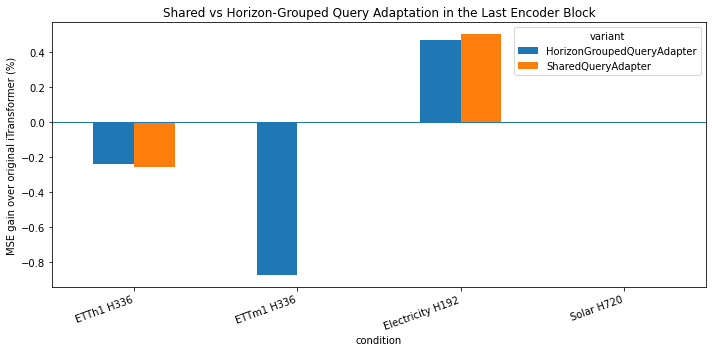

In [18]:
plot_df = (
    results_df[
        [
            "dataset",
            "pred_len",
            "variant",
            "mse_gain_vs_iTransformer_%",
        ]
    ]
    .copy()
)

plot_df[
    "condition"
] = (
    plot_df[
        "dataset"
    ]
    +
    " H"
    +
    plot_df[
        "pred_len"
    ].astype(
        str
    )
)

plot_pivot = plot_df.pivot(
    index="condition",
    columns="variant",
    values="mse_gain_vs_iTransformer_%",
)

ax = plot_pivot.plot(
    kind="bar",
    figsize=(
        10,
        5,
    ),
)

ax.axhline(
    0.0,
    linewidth=1,
)

ax.set_ylabel(
    "MSE gain over original iTransformer (%)"
)

ax.set_title(
    "Shared vs Horizon-Grouped Query Adaptation in the Last Encoder Block"
)

plt.xticks(
    rotation=20,
    ha="right",
)

plt.tight_layout()
plt.show()


# 17. Decision rule

This section implements the matched horizon-specific topology-transfer mechanism. Predictive-utility source sets are computed from training data and then imposed on the neural forecaster as specified in the paper.
